In [ ]:
import scanpy as sc
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import gc
from scvi.model import SCANVI
from scvi.model import SCVI
import seaborn as sns
import os
import math
import anndata as ad
import re
import sys, types
import matplotlib as mpl

modname = "pandas.core.indexes.numeric"
if modname not in sys.modules:
    m = types.ModuleType(modname)

    # Old pandas exposed these names; in pandas>=2 they were removed.
    # Alias them to Index so pickle imports resolve.
    m.NumericIndex = pd.Index
    m.Int64Index = pd.Index
    m.UInt64Index = pd.Index
    m.Float64Index = pd.Index

    sys.modules[modname] = m

mpl.rcParams['figure.dpi'] = 200
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
outdir = '../data/validations/'
refdir = '../../../data/GBM_LEAP_annotations/'
sc.settings.figdir = outdir

# Data prep

In [ ]:
# Load parse anndata and metadata
adata_query_parse = ad.concat([
    sc.read_h5ad(os.path.join(outdir, 'parse', 'adata_query_QC.h5ad')),
], merge = 'same')

adata_query_parse.obs['study'] = 'parse_data'
adata_query_parse.obs['cell_type'] = 'Unknown'
adata_query_parse.obs['batch_category'] = adata_query_parse.obs['sample']
adata_query_parse.X = adata_query_parse.layers['counts']

# filter for samples only necessary for this analysis
remove_samples = [
 'cd11b- bulk',
 'cd11b- cd44+',
 'cd11b- cd44-',
 'cd44- E25-MOI: 0.125',
 'cd44- E30-MOI: 0.125',
 'cd44- E25-MOI:0.5',
 'cd44- E30-MOI:0.5'
]
adata_query_parse = adata_query_parse[~adata_query_parse.obs['sample_name'].isin(remove_samples)].copy()

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
# Load Xenium data
adata_query_org = ad.concat([
    sc.read_h5ad(os.path.join(outdir, 'all_EGFP', 'AT410_E25_E30_D7_D14_D28.h5ad')),
], merge = 'same')
adata_query_org.obs['study'] = 'xenium_GFP_data'
adata_query_org.obs['cell_type'] = 'Unknown'
adata_query_org.obs['batch_category'] = adata_query_org.obs['batch']
adata_query_org.X = adata_query_org.layers['counts']

# filter organoid conditions not used in the main analysis (e.g. 0.5 lenti);
adata_query_org = adata_query_org[~adata_query_org.obs['batch'].str.contains('0_5')]
adata_query_org = adata_query_org[~adata_query_org.obs['batch'].str.contains('_5')]

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
adata_reference = sc.read_h5ad(os.path.join(refdir, 'GBM_LEAP_annotations_v2.22_04_25.webatlas.h5ad'))
adata_reference.obs['study'] = 'GBM-space'
adata_reference.obs['batch_category'] = adata_reference.obs['sample']
adata_reference.obs['cell_type'] = adata_reference.obs['annotation_coarse']

In [ ]:
intersecting_var = adata_reference.var_names[adata_reference.var_names.isin(adata_query_org.var_names)].tolist()

adata_reference = adata_reference[:,intersecting_var].copy()
adata_query_org = adata_query_org[:, intersecting_var].copy()
adata_query_parse = adata_query_parse[:, intersecting_var].copy()

gc.collect()

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


3717

In [ ]:
condition_key = 'study'
cell_type_key = 'cell_type'
cols = ['cell_id', 'sample', 'cell_type', 'phase', 'batch_category', 'study','n_genes_by_counts'] #mt_frac
adata_full = adata_reference.concatenate(adata_query_parse)
adata_full = adata_full.concatenate(adata_query_org)
adata_full.obs = adata_full.obs[cols]

/tmp/ipykernel_1425459/4237979770.py:2: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_full = adata_reference.concatenate(adata_query_parse)
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  u

In [ ]:
del(adata_reference)
gc.collect()

10

In [ ]:
## save query df metadata:

# parse
adata_query_parse.obs[['cell_id', 'batch_category', 'sample_name']]\
    .to_csv(os.path.join(outdir, 'combined_label_transfer', 'parse_metadata.csv'))
adata_query_org.obs['sample_name'] = adata_query_org.obs['cell_line'].astype(str)+': '+adata_query_org.obs['time'].astype(str)
adata_query_org.obs[['cell_id', 'batch_category', 'sample_name']]\
    .to_csv(os.path.join(outdir, 'combined_label_transfer', 'xenium_org_metadata.csv'))

In [ ]:
gc.collect()

# redo cell cycle and phasing

url = "https://raw.githubusercontent.com/theislab/scanpy_usage/master/180209_cell_cycle/data/regev_lab_cell_cycle_genes.txt"
genes = pd.read_csv(url, header=None)[0].tolist()
s_genes  = genes[:43]
g2m_genes = genes[43:]

sc.tl.score_genes_cell_cycle(
        adata_full,
        s_genes=s_genes,
        g2m_genes=g2m_genes
    )

       'GMNN', 'WDR76', 'SLBP', 'CCNE2', 'UBR7', 'POLD3', 'ATAD2', 'CDC45',
       'TIPIN', 'DSCC1', 'USP1', 'CLSPN', 'POLA1', 'CHAF1B', 'E2F8'],
      dtype='object')
       'GTSE1', 'KIF20B', 'HJURP', 'HN1', 'NCAPD2', 'DLGAP5', 'CDCA8', 'ECT2',
       'KIF23', 'ANLN', 'LBR', 'CENPE', 'G2E3', 'GAS2L3'],
      dtype='object')


# Run scVI

In [ ]:
# check the UMAP without phase as a covariate
SCVI.setup_anndata(
    adata_full,
    batch_key = "batch_category",
    labels_key = 'cell_type',
    categorical_covariate_keys=['phase', 'study'],
)

In [ ]:
vae = SCVI(adata_full,
           n_hidden = 1024,
           n_layers = 2,
           n_latent = 50,
           gene_likelihood = 'nb',
           dispersion = 'gene-batch',
           use_observed_lib_size = True)

In [ ]:
vae.train(train_size=0.99, max_epochs=50, batch_size = 1024) 

In [ ]:
vae.save(os.path.join(outdir, 'combined_label_transfer', "vae_nohvg_all_new/"), overwrite=True)

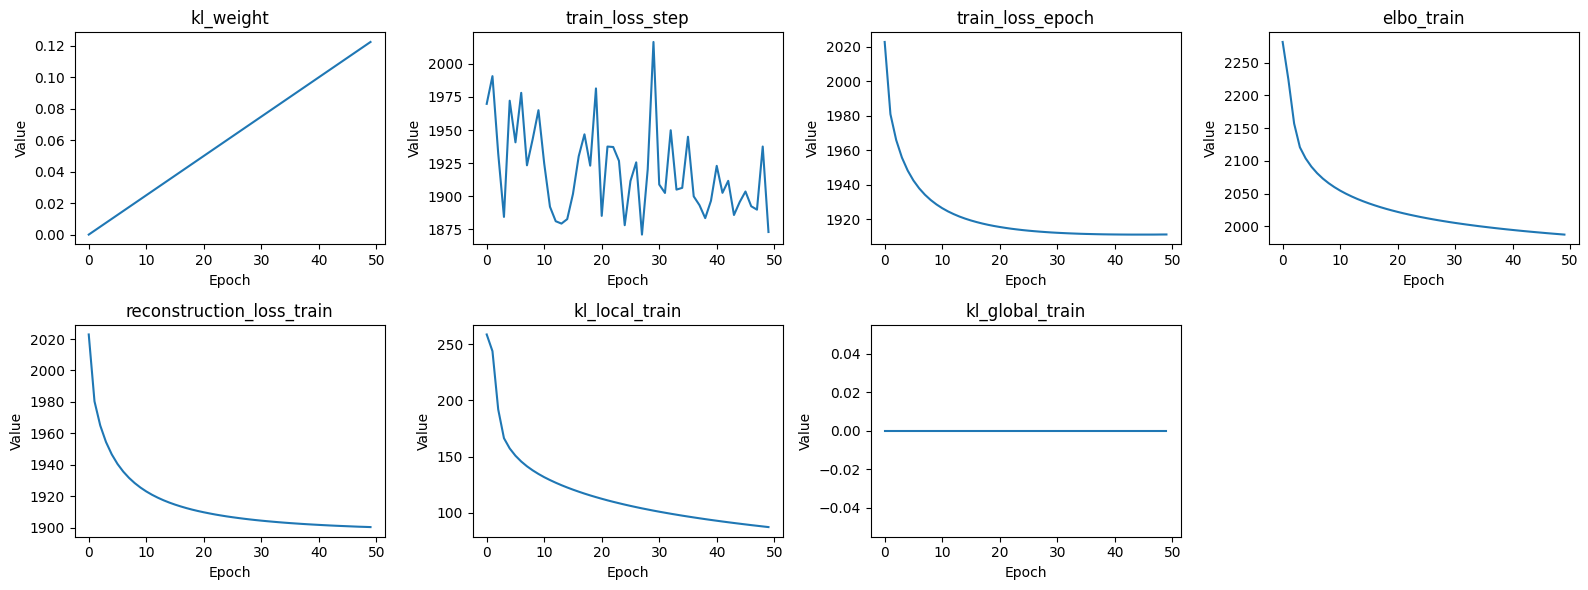

In [ ]:
keys = vae.history_.keys()
hist = vae.history_
n = len(keys)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))

# flatten axes for easy indexing
axes = axes.ravel()

for ax, k in zip(axes, keys):
    ax.plot(hist[k])
    ax.set_title(k)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Value")

# remove unused axes if there are any
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
vae = SCVI.load(os.path.join(outdir, 
                             "combined_label_transfer/vae_nohvg_all/"), 
                adata=adata_full)

INFO     File                                                                                                      
         /lustre/scratch124/cellgen/bayraktar/gd11/projects/GBM_space_output/validations/combined_label_transfer/va
         e_nohvg_all/model.pt already downloaded                                                                   


In [ ]:
adata_full.obsm["X_scVI"] = vae.get_latent_representation()

In [ ]:
sc.pp.neighbors(adata_full, use_rep="X_scVI")
sc.tl.umap(adata_full)

In [ ]:
sc.pl.umap(
    adata_full,
    color=["study", "cell_type"],
    frameon=False,
    ncols=1,
    s=0.1
)

In [ ]:
adata_full.write_h5ad(os.path.join(outdir, "combined_label_transfer/adata_combined_nohvg_all_new.h5ad"))

# Run SCANVI

In [ ]:
scanvae = SCANVI.from_scvi_model(vae, unlabeled_category = "Unknown")

In [ ]:
scanvae.train(max_epochs=10)

In [ ]:
scanvae.save(os.path.join(outdir, "combined_label_transfer/scanvae_nohvg_all_new/"), overwrite=True)

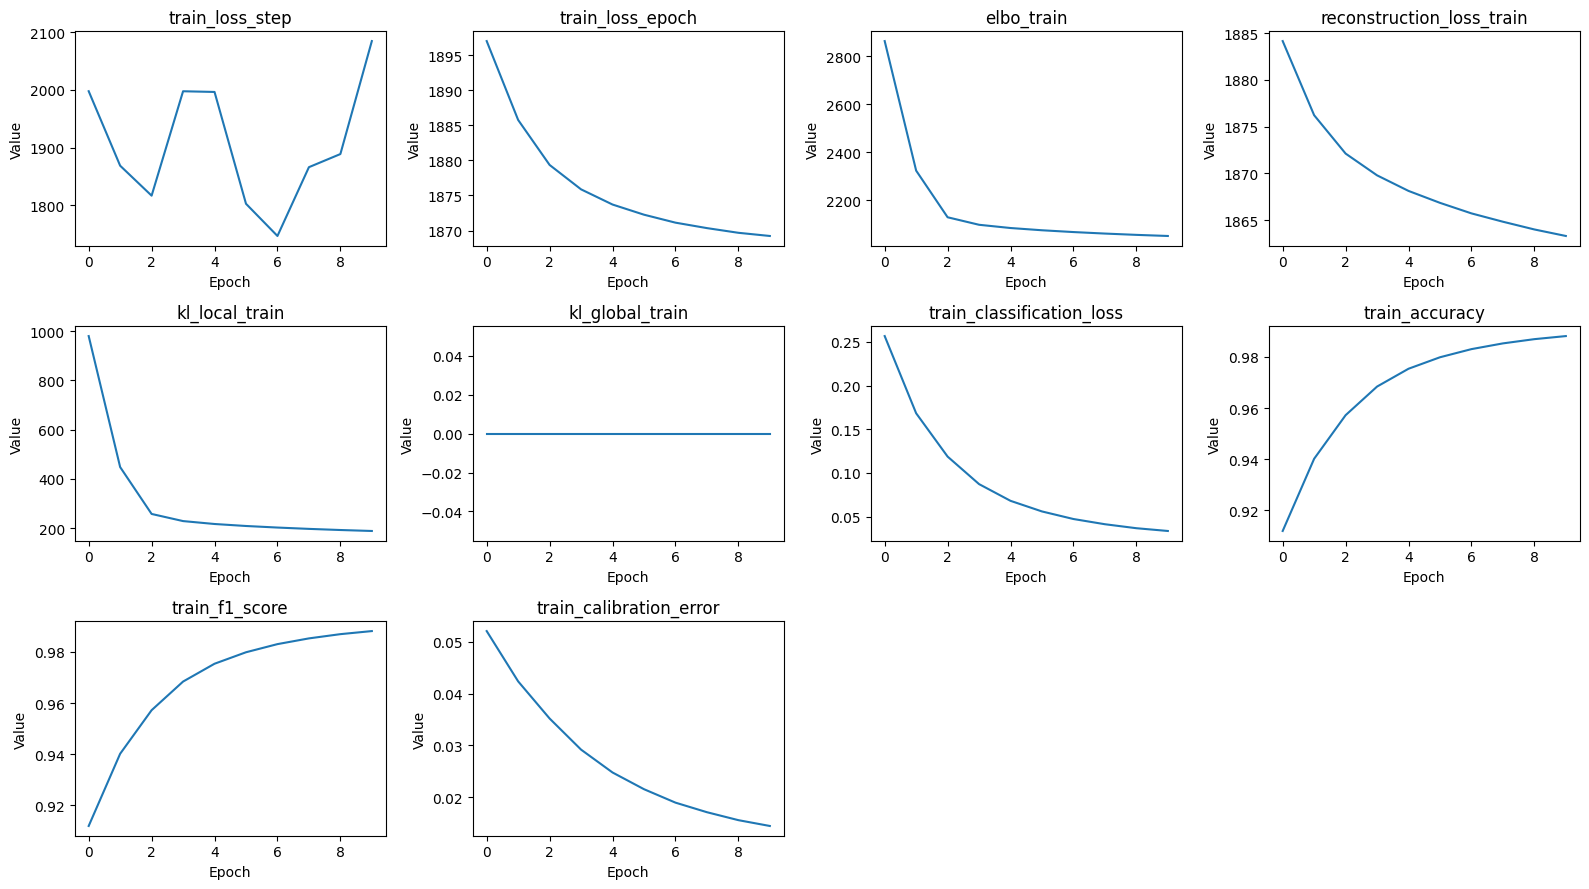

In [ ]:
keys = scanvae.history_.keys()
hist = scanvae.history_
n = len(keys)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))

# flatten axes for easy indexing
axes = axes.ravel()

for ax, k in zip(axes, keys):
    ax.plot(hist[k])
    ax.set_title(k)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Value")

# remove unused axes if there are any
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Load SCANVI results

In [ ]:
adata_full = sc.read_h5ad(os.path.join(outdir, "combined_label_transfer/adata_combined_nohvg_all.h5ad"))

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
# add query sample metadata
parse_metadata = pd.read_csv(os.path.join(outdir, 'combined_label_transfer', 'parse_metadata.csv'), index_col=0)
xenium_org_metadata = pd.read_csv(os.path.join(outdir, 'combined_label_transfer', 'xenium_org_metadata.csv'), index_col=0)

# add lenti data to org metadata and clean up for viz - ONLY USE 0.25
xenium_org_metadata['lenti'] = [str(re.sub('^.*-MOI(.*?)-.*$', '\\1', i)) for i in xenium_org_metadata['batch_category']]
xenium_org_metadata['lenti'] = [str(re.sub('_', '.', i)) for i in xenium_org_metadata['lenti']]
xenium_org_metadata['lenti'] = [str(re.sub('^\\.5', '0.5', i)) for i in xenium_org_metadata['lenti']]
xenium_org_metadata['lenti'] = [str(re.sub('^.*0.25.*$', '0.25', i)) for i in xenium_org_metadata['lenti']]


xenium_org_metadata['sample_name'] = xenium_org_metadata['sample_name']+' ('+xenium_org_metadata['lenti']+')'

xenium_org_metadata['sample_name'] = [re.sub('^e', 'E', i) for i in xenium_org_metadata['sample_name']]
xenium_org_metadata = xenium_org_metadata.drop('lenti', axis=1)

# combine
query_metadata = pd.concat([parse_metadata, xenium_org_metadata])

# merge with anndata
adata_full.obs = adata_full.obs.reset_index().merge(query_metadata, on = ['batch_category', 'cell_id'], how = 'left').set_index('index')
adata_full.obs['sample_name'] = np.where(adata_full.obs['sample_name'].isnull(), 'GBMspace', adata_full.obs['sample_name'])

In [ ]:
scanvae = SCANVI.load(os.path.join(outdir, "combined_label_transfer/scanvae_nohvg_all/"), adata=adata_full)

INFO     File                                                                                                      
         /lustre/scratch124/cellgen/bayraktar/gd11/projects/GBM_space_output/validations/combined_label_transfer/sc
         anvae_nohvg_all/model.pt already downloaded                                                               


In [ ]:
adata_full.obs['predictions'] = scanvae.predict()

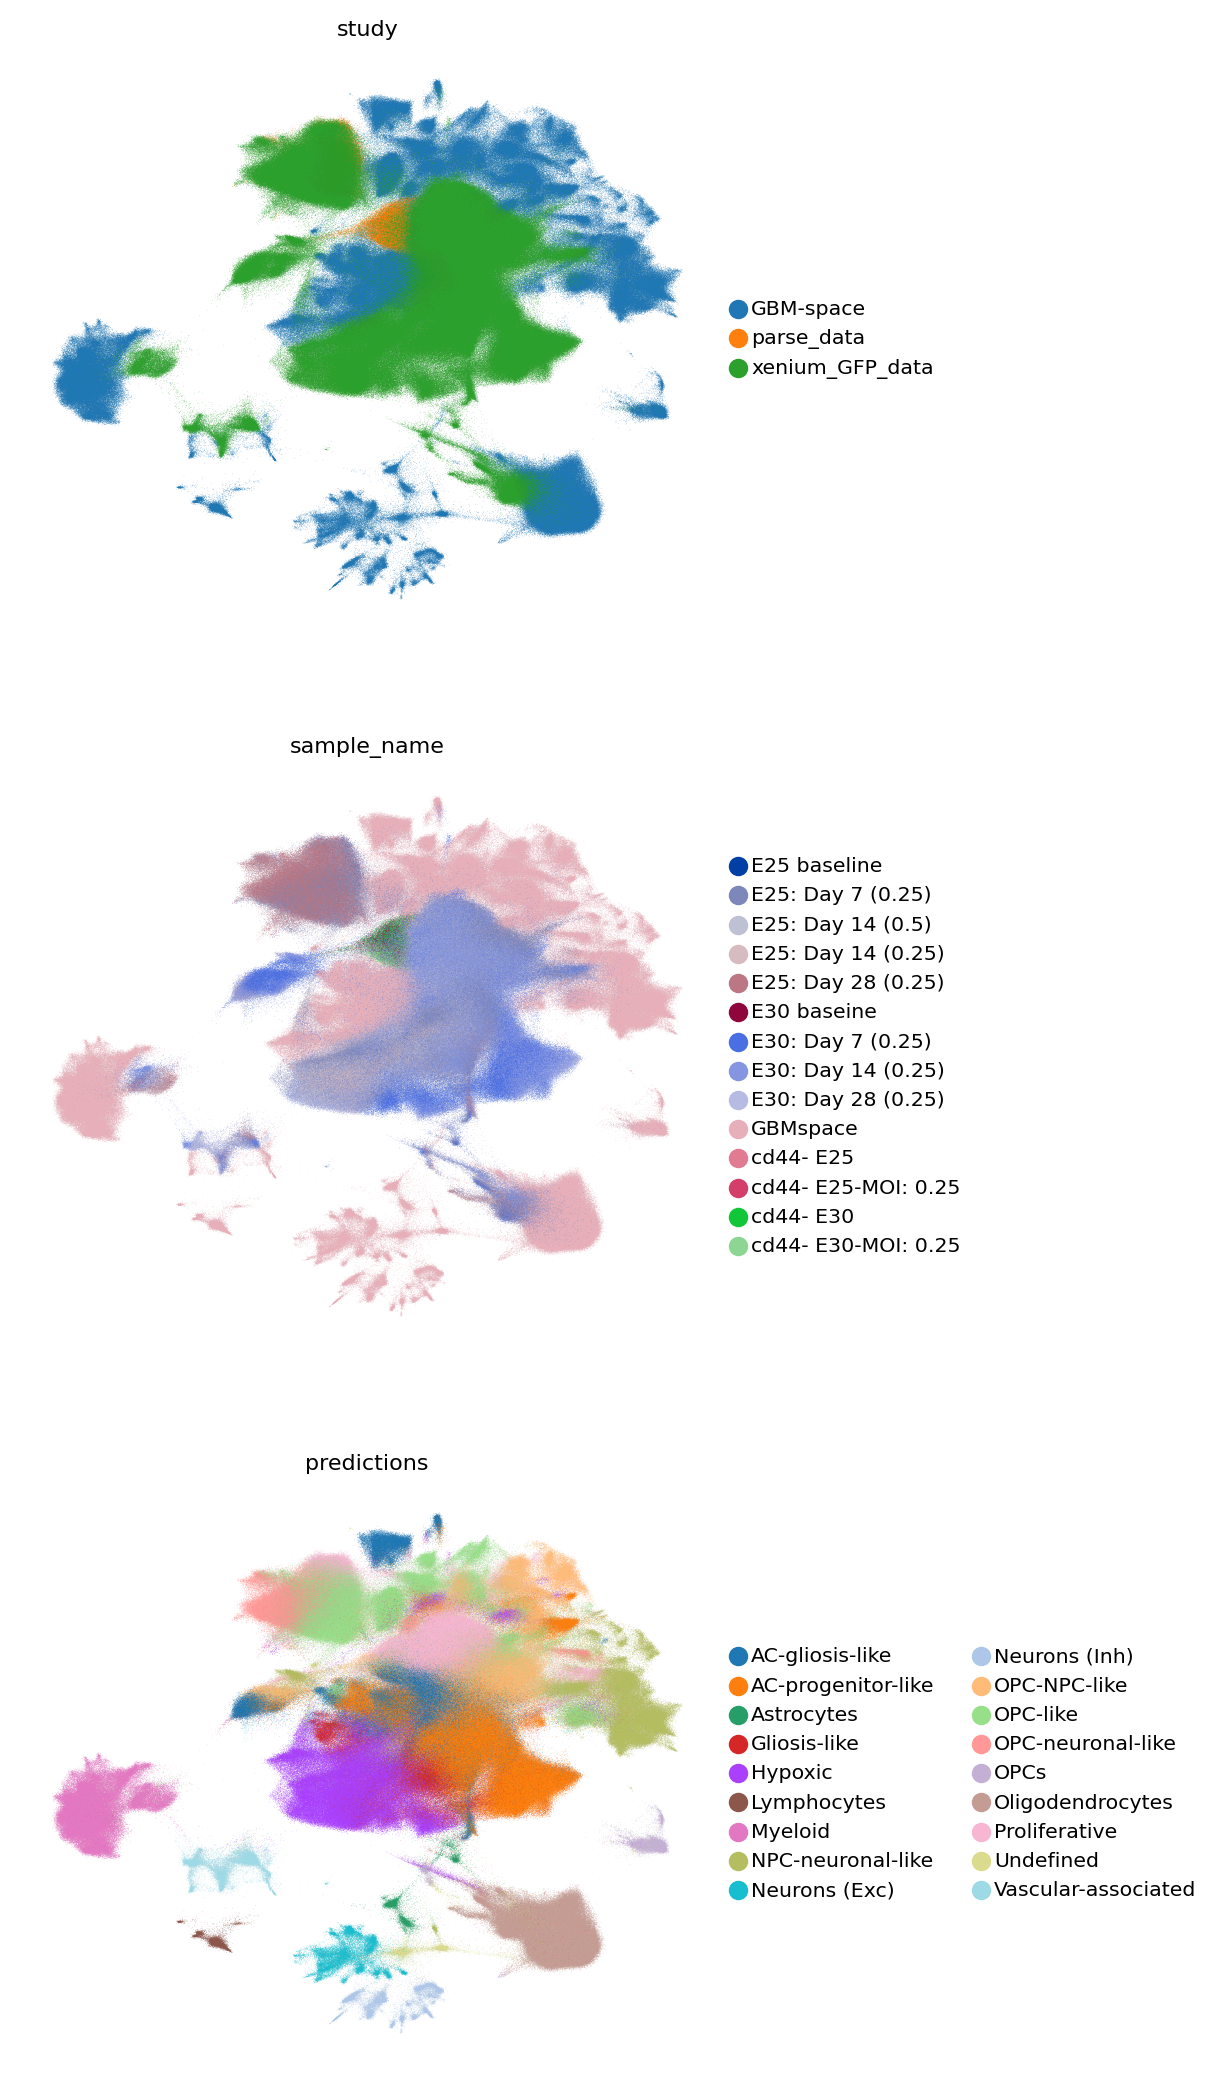

In [ ]:
sc.pl.umap(
    adata_full,
    color=["study", 'sample_name', 'predictions'],
    frameon=False,
    ncols=1,
    size = 0.1
)

In [ ]:
# Global figure settings
sc.set_figure_params(
    dpi=100,
    dpi_save=600,
    frameon=False,
    vector_friendly=True,
    fontsize=8,
    figsize=(4, 4)
)

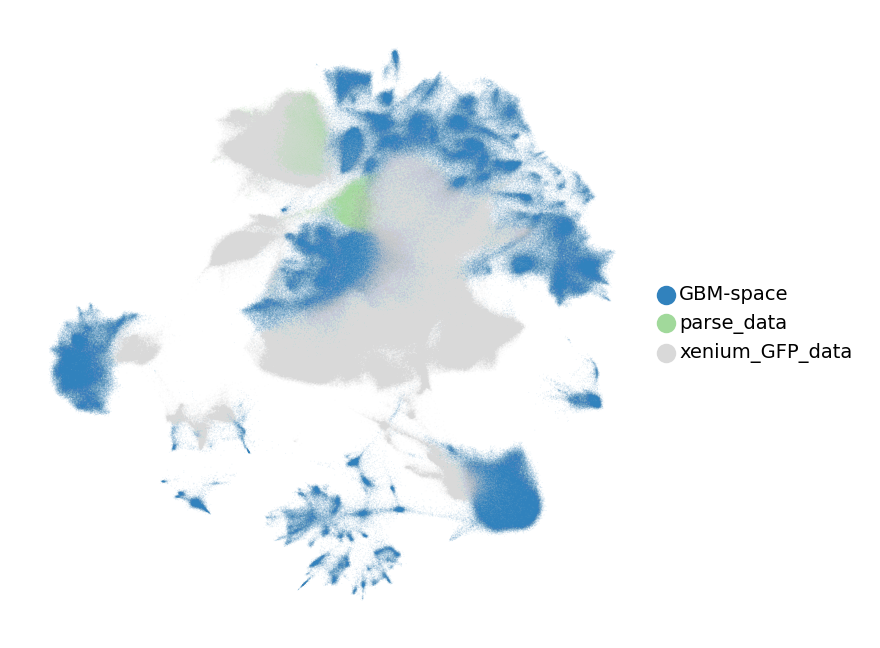

In [ ]:
# UMAP
ax = sc.pl.umap(
    adata_full[~adata_full.obs['sample_name'].str.contains('0.5')],
    color=["study"],
    size=0.5,
    alpha=0.1,
    #palette="tab20b",
    legend_loc="right margin",
    legend_fontsize=7,
    legend_fontoutline=1,
    frameon=False,
    title="",
    show=False
)

# Fine Matplotlib control
ax.set_xlabel("", fontsize=8)
ax.set_ylabel("", fontsize=8)
ax.tick_params(
    left=False,
    bottom=False,
    labelleft=False,
    labelbottom=False
)

for collection in ax.collections:
    collection.set_rasterized(True)

plt.savefig(os.path.join(outdir, "combined_label_transfer/sample_name_umap.pdf"), 
            dpi=400, bbox_inches="tight")

In [ ]:
from matplotlib.colors import to_hex
from itertools import cycle
from matplotlib import colormaps

color_palette = {
    "Gliosis-like": "#cd853f",
    "AC-gliosis-like": "#a0522d",
    "Hypoxic": "#bc8f8f",
    "AC-progenitor-like": "#8b4513",
    
    "NPC-neuronal-like": "#c0bdbd",
    
    "OPC-like": "#c0d860",
    "OPC-NPC-like": "#9ec85e",
    "OPC-neuronal-like": "#acd748",
    
    "Proliferative": "#35aee3",
    "NA": "#D3D3D3"
}


cats = adata_full.obs['predictions'].cat.categories
tab20 = cycle(to_hex(c) for c in colormaps["tab20"].colors)
used = {c.lower() for c in color_palette.values()}

expanded_palette = {
    cat: color_palette.get(
        cat,
        next(c for c in tab20 if c.lower() not in used)
    )
    for cat in cats
}

In [ ]:
# UMAP
ax = sc.pl.umap(
    adata_full[~adata_full.obs['sample_name'].str.contains('0.5')],
    color=["predictions"],
    size=0.05,
    alpha=0.5,
    palette=expanded_palette,
    legend_loc="right margin",
    legend_fontsize=7,
    legend_fontoutline=1,
    frameon=False,
    title="",
    show=False
)

# Fine Matplotlib control
ax.set_xlabel("", fontsize=8)
ax.set_ylabel("", fontsize=8)
ax.tick_params(
    left=False,
    bottom=False,
    labelleft=False,
    labelbottom=False
)

for collection in ax.collections:
    collection.set_rasterized(True)

plt.savefig(os.path.join(outdir, "combined_label_transfer/predictions_umap.pdf"), 
            dpi=400, bbox_inches="tight")

In [ ]:
import squidpy as sq
from matplotlib.colors import ListedColormap

In [ ]:
annotation = 'annotation_coarse'

sample_list = [
'AT404-BRA-0-ORG-C-S36-B2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-S46-C1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-wk4-S3-A1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-S6-A1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-wk4-S53-C2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-wk4-S43-C1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-S56-C2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-S16-A2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-wk4-S63-D1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-wk4-S13-A2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-wk4-S23-B1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-S66-D1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-wk4-S73-D2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-S26-B1__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-wk4-S33-B2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad',
'AT404-BRA-0-ORG-C-S76-D2__filt_cells_filt_genes_raw_log1pnorm_counts.h5ad'
]

#sample_list = ["AT402_BRN_0_ORG_C_1-s3__all_cells_all_genes_raw_counts.h5ad", 
#"AT402_BRN_0_ORG_P_1-s3__all_cells_all_genes_raw_counts.h5ad", 
#"AT402_BRN_0_ORG_C_1-s4__all_cells_all_genes_raw_counts.h5ad", 
#"AT402_BRN_0_ORG_P_1-s4__all_cells_all_genes_raw_counts.h5ad"]

wd = '../data/validations/GBO_engrafted_CD44/'
plot_dir = '../data/validations/GBO_engrafted_CD44/sc_plots/'
sc.settings.figdir = plot_dir

markers = pd.read_csv('../data/validations/data/markers.tsv', sep = '\t')

In [ ]:
sections = {}
for sample in sample_list:
    
    sp = os.path.join(wd,'{}'.format(sample))
    tangram_out = os.path.join(wd, 'tangram','{}_{}_res.csv'.format(annotation, sample))

    # tangram res
    tangram_res = pd.read_csv(tangram_out, index_col = 0)
    
    # load adata
    sections[sample] = sc.read_h5ad(sp)
    sections[sample].obs = sections[sample].obs.reset_index()\
                            .merge(tangram_res.reset_index(), on = 'index').set_index('index')

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


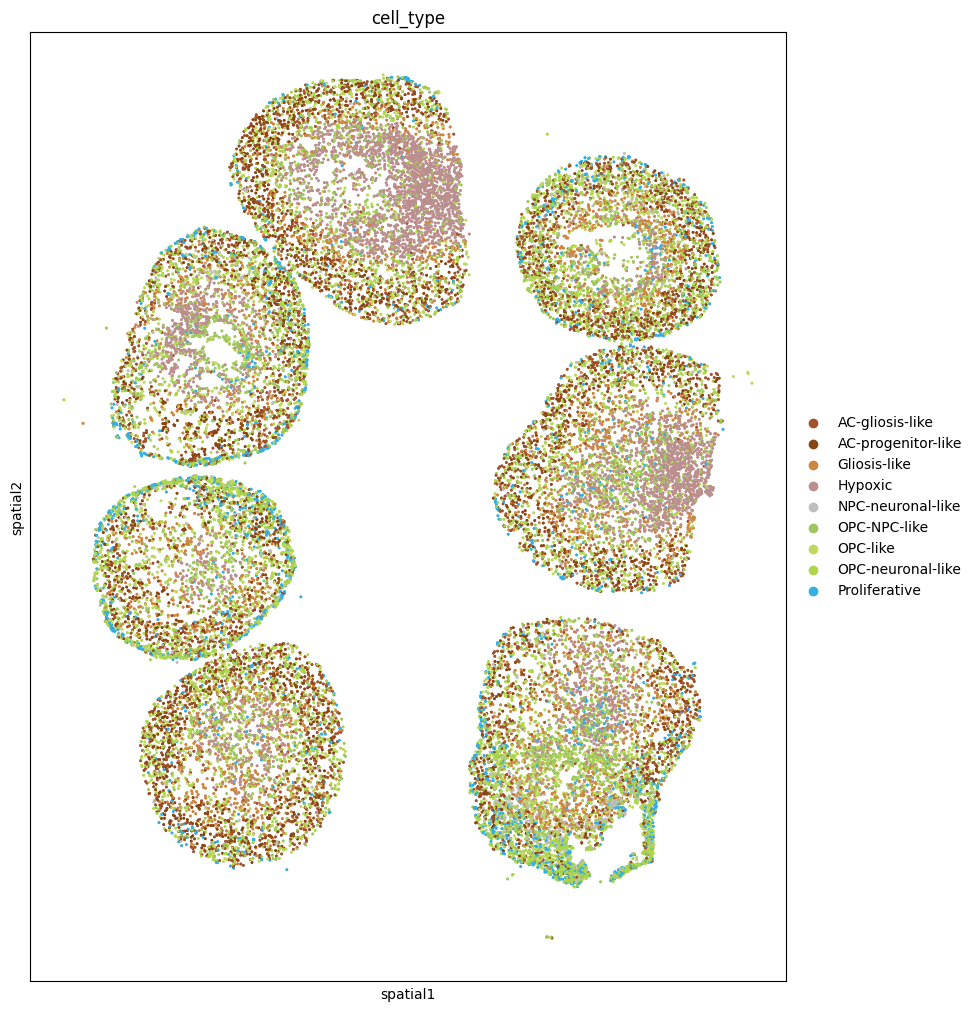

In [ ]:
sample = sample_list[4]
counts = 150
size = 5

# test
sp_ad = sections[sample].copy()
sp_ad = sp_ad[(sp_ad.obs['total_counts']>=counts) & (sp_ad.obs['cell_area']>=size),:]

cmap = ListedColormap(
    [color_palette[c] for c in sorted(list(set(sp_ad.obs['cell_type'])))],
    name="celltype_cmap"
)

# spatial plot
with plt.rc_context({"figure.figsize": (10, 10)}):
        sq.pl.spatial_scatter(
            sp_ad[sp_ad.obs['cell_type_probability']>0.4],
            spatial_key="spatial",
            color="cell_type",
            img=False,
            shape=None,
            palette=cmap
        )

In [ ]:
sp_ad.obs = sp_ad.obs.reset_index().merge(
    adata_full[adata_full.obs['batch_category'].isin([sample])].obs[['cell_id', 'predictions']], 
    on = 'cell_id', how = 'left'
).set_index('index')

In [ ]:
sp_ad_GFP = sp_ad[~sp_ad.obs['predictions'].isnull()]

sp_ad_GFP.obs['predictions'] = np.where(sp_ad_GFP.obs['predictions']=='OPCs', 
                                        'OPC-like', sp_ad_GFP.obs['predictions'])

cmap_GFP = ListedColormap(
    [color_palette[c] for c in sorted(list(set(sp_ad_GFP.obs['predictions'])))],
    name="celltype_cmap"
)


/tmp/ipykernel_405980/1277309753.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  sp_ad_GFP.obs['predictions'] = np.where(sp_ad_GFP.obs['predictions']=='OPCs',


In [ ]:
with plt.rc_context({"figure.figsize": (10, 10)}):

    # plot NA points first (background)
    ax = sq.pl.spatial_scatter(
        sp_ad[sp_ad.obs['predictions'].isnull()],
        spatial_key="spatial",
        color='predictions',
        na_color="lightgrey",
        alpha=0.2,
        size=2,
        img=False,
        shape=None,
        return_ax=True
    )
    
    # plot non-NA points on top
    sq.pl.spatial_scatter(
        sp_ad_GFP,
        spatial_key="spatial",
        color='predictions',
        alpha=1.0,
        size=20,
        img=False,
        shape=None,
        ax=ax,
        palette=cmap_GFP
    )

/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]


/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


/software/conda/users/gd11/scverse_new/lib/python3.10/site-packages/squidpy/pl/_spatial_utils.py:976: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


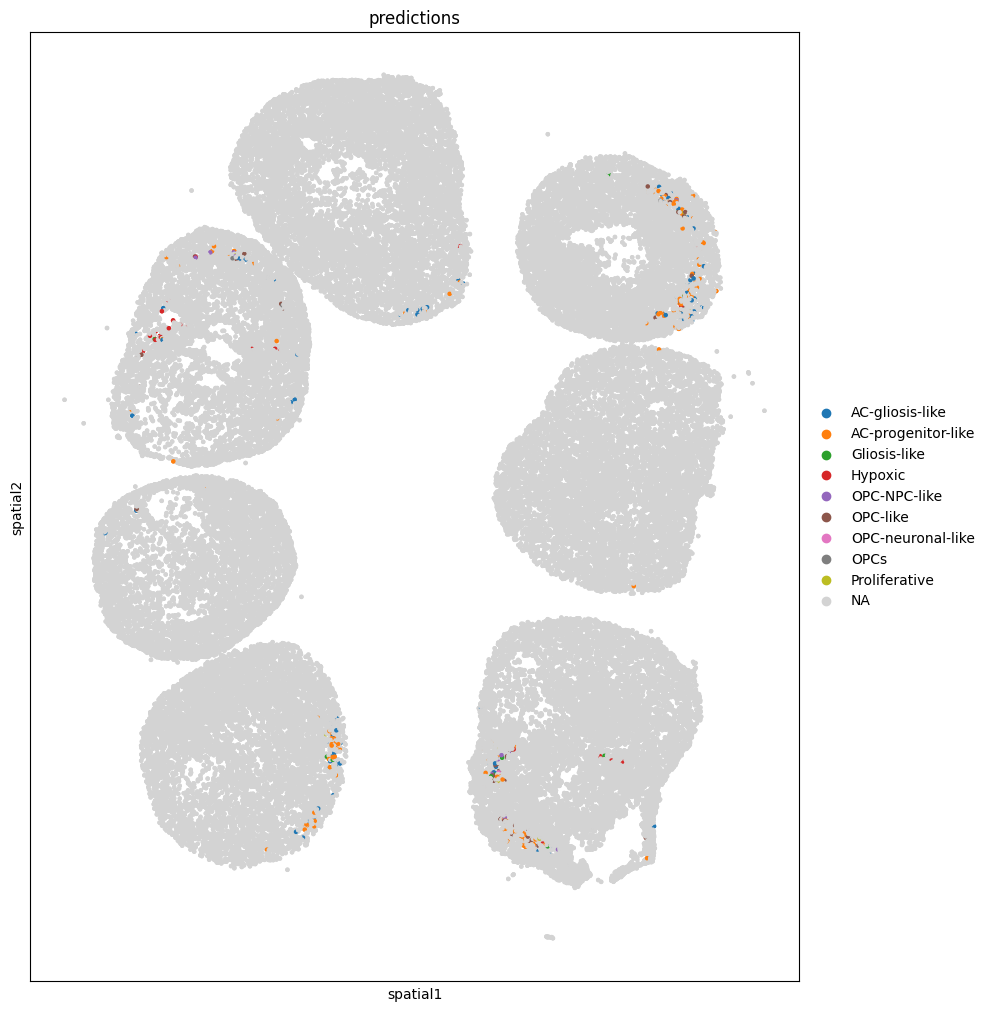

In [ ]:
# spatial plot
with plt.rc_context({"figure.figsize": (10, 10)}):
        sq.pl.spatial_scatter(
            sp_ad,
            spatial_key="spatial",
            color="predictions",
            na_color="lightgrey",
            size = 20,
            img=False,
            shape=None
        )

In [ ]:
adata_full.obs

,cell_id,sample,cell_type,phase,batch_category,study,n_genes_by_counts,_scvi_batch,_scvi_labels,sample_name,bio_sample,predictions
index,,,,,,,,,,,,
cellranger-arc201_count_adf395d2259f5577779c070f7ebe5b76#CATTATCTCATTCATC-1-0-0,cellranger-arc201_count_adf395d2259f5577779c07...,cellranger-arc201_count_adf395d2259f5577779c07...,Proliferative,G2M,cellranger-arc201_count_adf395d2259f5577779c07...,GBM-space,9592,147,15,NaN,reference,Proliferative
cellranger-arc201_count_adf395d2259f5577779c070f7ebe5b76#GGTTATATCCTAACGG-1-0-0,cellranger-arc201_count_adf395d2259f5577779c07...,cellranger-arc201_count_adf395d2259f5577779c07...,Neurons (Exc),G1,cellranger-arc201_count_adf395d2259f5577779c07...,GBM-space,11215,147,8,NaN,reference,Neurons (Exc)
cellranger-arc201_count_adf395d2259f5577779c070f7ebe5b76#GGTTATATCTGTAATG-1-0-0,cellranger-arc201_count_adf395d2259f5577779c07...,cellranger-arc201_count_adf395d2259f5577779c07...,Vascular-associated,G1,cellranger-arc201_count_adf395d2259f5577779c07...,GBM-space,10725,147,17,NaN,reference,Vascular-associated
cellranger-arc201_count_adf395d2259f5577779c070f7ebe5b76#TCGCGAGGTCAAAGGG-1-0-0,cellranger-arc201_count_adf395d2259f5577779c07...,cellranger-arc201_count_adf395d2259f5577779c07...,Astrocytes,G1,cellranger-arc201_count_adf395d2259f5577779c07...,GBM-space,10531,147,2,NaN,reference,Astrocytes
cellranger-arc201_count_adf395d2259f5577779c070f7ebe5b76#GCCTACTTCTATGACA-1-0-0,cellranger-arc201_count_adf395d2259f5577779c07...,cellranger-arc201_count_adf395d2259f5577779c07...,OPC-like,G2M,cellranger-arc201_count_adf395d2259f5577779c07...,GBM-space,9967,147,11,NaN,reference,OPC-like
...,...,...,...,...,...,...,...,...,...,...,...,...
leagmjkc-1-1,leagmjkc-1,NaN,Unknown,G1,AT402-BRA-0-ORG-C-E25-wk4-S73-D2__filt_cells_f...,xenium_GFP_data,345,13,18,NaN,E25_xenium_w4,Gliosis-like
leahhmfb-1-1,leahhmfb-1,NaN,Unknown,G2M,AT402-BRA-0-ORG-C-E25-wk4-S73-D2__filt_cells_f...,xenium_GFP_data,356,13,18,NaN,E25_xenium_w4,AC-gliosis-like
leajadop-1-1,leajadop-1,NaN,Unknown,S,AT402-BRA-0-ORG-C-E25-wk4-S73-D2__filt_cells_f...,xenium_GFP_data,216,13,18,NaN,E25_xenium_w4,AC-gliosis-like
